# Component: East Antarctic Ice Sheet (EAIS)

This notebook calibrates, validates, and projects the EAIS component of GMSL rise.

**Key features:**
- IMBIE observations (1992–2020) show near-zero net mass change with no detectable
  temperature sensitivity (BIC confirms linear/trend-only over quadratic).
- EAIS mass balance is dominated by precipitation: warming increases snowfall via
  Clausius–Clapeyron, partially offset by marginal dynamic losses.
- **Projection approach:** RCM-derived SMB sensitivity (`EAIS_SMB` from
  `smb_projections.py`), not the DOLS fit. Same rationale as Greenland: the IMBIE
  record is too short and noisy for a data-driven T regression to capture the
  accumulation response. Literature values (Frieler et al. 2015; Ligtenberg et al.
  2013) constrain C_T ≈ +60 ± 20 Gt/yr/°C GMST (positive = mass gain = negative SLR).
- DOLS fit retained as a diagnostic confirming consistency with near-zero contribution.

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-poster')

sys.path.insert(0, '.')
from slr_data_readers import read_imbie_west_antarctica, read_berkeley_earth
from bayesian_dols import (
    build_level_design_vectors, fit_bayesian_level,
    calibrate_exponential_prior, check_convergence,
)
from slr_projections import project_component_level_ensemble
from component_analysis import apply_sigma_taper, compute_component_rates
from component_projections import read_ipcc_component_nc, ipcc_extract
from component_plotting import (
    SSP_COLORS, COMP_COLORS, M_TO_MM,
    plot_component_projection_twopanel,
    plot_component_histogram,
    plot_component_ridge,
)
from smb_projections import EAIS_SMB, project_smb_ensemble

H5_PATH = '../data/processed/slr_processed_data.h5'
RAW_DIR = '../data/raw'
FIG_DIR = '../figures'
CONF_BASE = f'{RAW_DIR}/ipcc_ar6/slr/ar6/global/confidence_output_files'

BASELINE_YEAR = 2005.0
N_SAMPLES = 2000

## 1. Data Loading

In [2]:
# ── IMBIE East Antarctica (satellite-era mass balance, 1992–2020) ──
# Use read_imbie_west_antarctica for all IMBIE mm-format files — same column
# layout. Reader converts mm → m and fixes negative-sigma quirk.
df_eais = read_imbie_west_antarctica(
    f'{RAW_DIR}/ice_sheets/antarctica/imbie_east_antarctica_2021_mm.csv')

# Annualize (reader output is already in meters — no further conversion)
t = df_eais['decimal_year'].values
year_int = np.floor(t).astype(int)
unique_years = np.unique(year_int)
eais_year = unique_years.astype(float) + 0.5
eais_H = np.array([df_eais['cumulative_mass_balance'].values[year_int == yr][-1]
                    for yr in unique_years])
eais_sigma = np.array([np.abs(df_eais['cumulative_mass_balance_sigma'].values[year_int == yr][-1])
                        for yr in unique_years])
bl_idx = np.argmin(np.abs(eais_year - BASELINE_YEAR))
eais_rebase = eais_H - eais_H[bl_idx]

# ── Berkeley Earth monthly GMST (for DOLS diagnostic and SSP projections) ──
df_temp = pd.read_hdf(H5_PATH, key='harmonized/df_berkeley_h')
temp_monthly = df_temp['temperature'].values
temp_time_monthly = (df_temp.index.year
                     + (df_temp.index.month - 0.5) / 12.0).values

print(f'EAIS IMBIE: {eais_year[0]:.0f}–{eais_year[-1]:.0f}, {len(eais_year)} points')
print(f'EAIS cumulative at end: {eais_rebase[-1]*M_TO_MM:.1f} mm')

# ── SMB sensitivity from literature ──
# EAIS mass balance is dominated by accumulation (Clausius–Clapeyron: ~5%/°C
# of ~1200 Gt/yr). C_T > 0 means warming → mass gain → negative SLR.
print(f'\nEAIS SMB sensitivity (from smb_projections.py):')
print(f'  C_T  = {EAIS_SMB.C_T:.0f} ± {EAIS_SMB.C_T_sigma:.0f} Gt/yr/°C GMST')
print(f'  Reference: {EAIS_SMB.reference}')
print(f'  In mm SLE/yr/°C: {EAIS_SMB.C_T * 1.0/362500.0 * M_TO_MM:.3f} (negative = SL fall)')

EAIS IMBIE: 1992–2020, 29 points
EAIS cumulative at end: -0.2 mm

EAIS SMB sensitivity (from smb_projections.py):
  C_T  = 60 ± 20 Gt/yr/°C GMST
  Reference: Frieler et al. (2015); Ligtenberg et al. (2013)
  In mm SLE/yr/°C: 0.166 (negative = SL fall)


In [3]:
# ══════════════════════════════════════════════════════════════════
# REFIT SWITCH — set False to skip fitting and load saved results.
# If loading fails (no HDF5 file), fitting runs automatically.
# ══════════════════════════════════════════════════════════════════
REFIT = True

from component_io import save_eais, load_component

if not REFIT:
    try:
        _loaded = load_component('eais')
        eais_proj = _loaded['projections']
        PROJ_YEARS = _loaded['proj_years']
        print(f'Loaded eais from HDF5: {list(eais_proj.keys())}')
    except (FileNotFoundError, KeyError) as e:
        print(f'Load failed ({e}) — falling back to REFIT=True')
        REFIT = True

## 2. DOLS Diagnostic Fit

DOLS rate–temperature fit on IMBIE data. This is a **diagnostic**, not the
projection model. It confirms that the IMBIE record shows no detectable
temperature sensitivity (BIC prefers linear/trend-only). The projection
uses RCM-derived SMB sensitivities instead (§4).

In [4]:
if REFIT:
    # ── Build design vectors ──
    design_eais = build_level_design_vectors(
        temperature_monthly=temp_monthly, time_monthly=temp_time_monthly,
        obs_times=eais_year)

    # ── Priors ──
    PRIOR_SCALE_A = calibrate_exponential_prior(prob_exceed=0.10, threshold=0.10/M_TO_MM)
    PRIOR_SCALE_B = calibrate_exponential_prior(prob_exceed=0.10, threshold=0.20/M_TO_MM)
    prior_kw = dict(prior_scale_a=PRIOR_SCALE_A, prior_scale_b=PRIOR_SCALE_B,
                    prior_c_mean=0.0003, prior_c_sigma=0.001,
                    prior_sigma_extra_scale=0.005, prior_H0_sigma=0.005)

    # ── Quadratic fit ──
    result_quad = fit_bayesian_level(
        H_obs=eais_rebase, sigma_obs=eais_sigma,
        I2_obs=design_eais['I2_obs'], I1_obs=design_eais['I1_obs'],
        I0_obs=design_eais['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2, seed=200, **prior_kw)

    # ── Linear fit ──
    result_lin = fit_bayesian_level(
        H_obs=eais_rebase, sigma_obs=eais_sigma,
        I2_obs=np.zeros_like(design_eais['I2_obs']),
        I1_obs=design_eais['I1_obs'], I0_obs=design_eais['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2, seed=300, **prior_kw)

    # ── BIC ──
    n = len(eais_year)
    rss_q = np.sum(result_quad.residuals**2)
    rss_l = np.sum(result_lin.residuals**2)
    bic_q = n * np.log(rss_q / n) + 5 * np.log(n)
    bic_l = n * np.log(rss_l / n) + 4 * np.log(n)
    delta_bic = bic_l - bic_q

    a_med = np.median(result_quad.posterior_samples[:, 0]) * M_TO_MM
    b_med = np.median(result_lin.posterior_samples[:, 1]) * M_TO_MM
    c_med = np.median(result_lin.posterior_samples[:, 2]) * M_TO_MM

    print(f'Linear:    b = {b_med:.4f} mm/yr/°C, c = {c_med:.4f} mm/yr, R² = {result_lin.r2:.4f}')
    print(f'Quadratic: a = {a_med:.4f} mm/yr/°C², R² = {result_quad.r2:.4f}')
    print(f'ΔBIC = {delta_bic:+.1f} ({"quadratic" if delta_bic > 2 else "linear"} preferred)')
    print(f'P(a>0) = {np.mean(result_quad.posterior_samples[:, 0] > 0)*100:.0f}%')
else:
    print('REFIT=False — skipping DOLS diagnostic fit (will load from HDF5 after projections)')

Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(mean=0.04 mm/yr/°C²), b~HN(0.1 mm/yr/°C), c~N(0.3, 1.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=0.754, b=-0.105, c=-0.053 mm/yr, σ_extra=0.10 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 821.27it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.008  ESS_bulk=204  ESS_tail=642
    alpha0: R-hat=1.026  ESS_bulk=181  ESS_tail=663
    trend: R-hat=1.013  ESS_bulk=235  ESS_tail=693
    log_sigma_extra: R-hat=1.017  ESS_bulk=209  ESS_tail=489
    H0: R-hat=1.023  ESS_bulk=194  ESS_tail=525
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.054, b=0.034, c=-0.024 mm/yr
  σ_extra: median=0.09 mm [0.00, 0.31]
  R² = 0.6796,  acceptance = 0.49
Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(mean=0.04 mm/yr/°C²), b~HN(0.1 mm/yr/°C), c~N(0.3, 1.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=0.000, b=0.072, c=-0.035 mm/yr, σ_extra=0.13 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 841.61it/s]

  Convergence diagnostics:
    dalpha_dT: R-hat=1.019  ESS_bulk=164  ESS_tail=422
    alpha0: R-hat=1.018  ESS_bulk=222  ESS_tail=503
    trend: R-hat=1.013  ESS_bulk=239  ESS_tail=509
    log_sigma_extra: R-hat=1.014  ESS_bulk=234  ESS_tail=340
    H0: R-hat=1.020  ESS_bulk=260  ESS_tail=694
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.043, b=0.025, c=-0.018 mm/yr
  σ_extra: median=0.09 mm [0.00, 0.31]
  R² = 0.5737,  acceptance = 0.48
Linear:    b = 0.0194 mm/yr/°C, c = -0.0178 mm/yr, R² = 0.5737
Quadratic: a = 0.0430 mm/yr/°C², R² = 0.6796
ΔBIC = +4.9 (quadratic preferred)
P(a>0) = 100%


## 3. Diagnostics & Validation

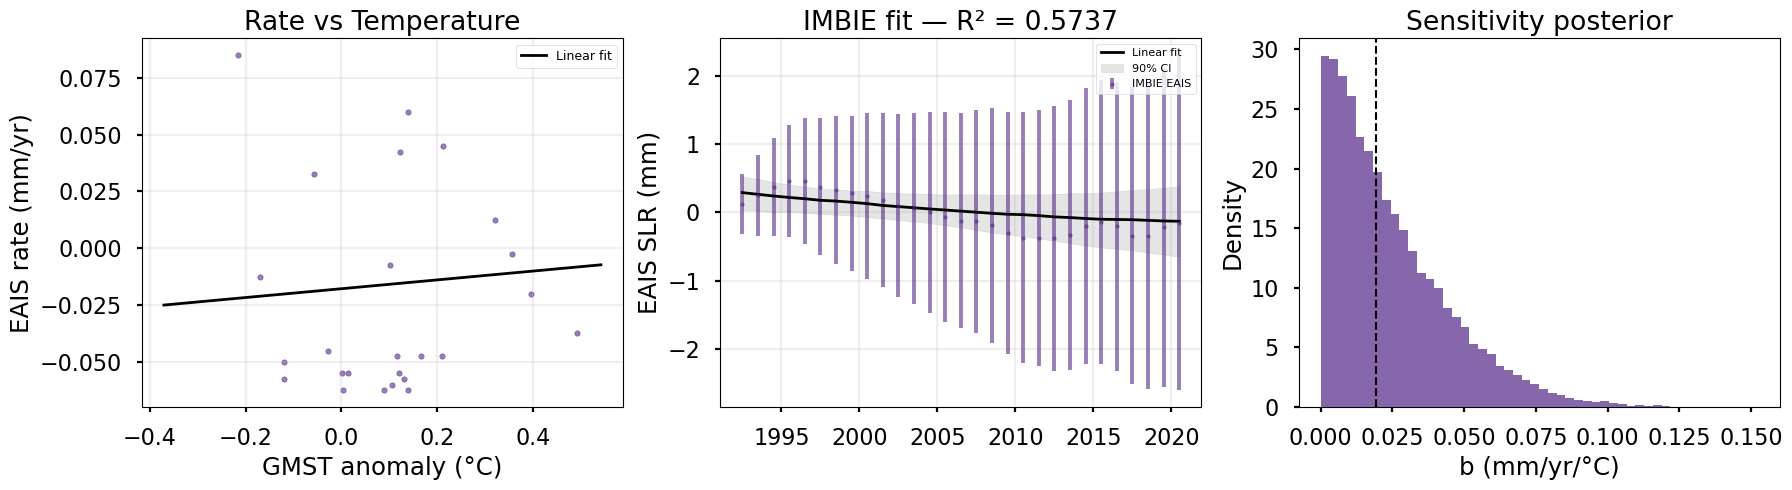

In [5]:
if REFIT:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Panel A: Rate vs T
    ax = axes[0]
    rates = compute_component_rates(eais_year, eais_rebase, window=2) * M_TO_MM
    yr_int = np.floor(temp_time_monthly).astype(int)
    T_ann = np.array([temp_monthly[yr_int == y].mean() for y in np.unique(yr_int)])
    T_ann_years = np.unique(yr_int) + 0.5
    T_at_eais = np.interp(eais_year, T_ann_years, T_ann)
    valid = np.isfinite(rates)
    ax.scatter(T_at_eais[valid], rates[valid], s=15, alpha=0.6, color=COMP_COLORS['EAIS'])
    T_grid = np.linspace(T_at_eais.min()-0.05, T_at_eais.max()+0.05, 100)
    ax.plot(T_grid, b_med * T_grid + c_med, 'k-', lw=2, label='Linear fit')
    ax.set_xlabel('GMST anomaly (°C)')
    ax.set_ylabel('EAIS rate (mm/yr)')
    ax.set_title('Rate vs Temperature')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

    # Panel B: IMBIE fit
    ax = axes[1]
    from component_analysis import model_ensemble_draws
    H_ens = model_ensemble_draws(result_lin, np.zeros_like(design_eais['I2_obs']),
                                  design_eais['I1_obs'], design_eais['I0_obs'])
    p5, p50, p95 = np.percentile(H_ens * M_TO_MM, [5, 50, 95], axis=0)
    ax.errorbar(eais_year, eais_rebase * M_TO_MM, yerr=2*eais_sigma*M_TO_MM,
                fmt='o', ms=3, color=COMP_COLORS['EAIS'], alpha=0.6, label='IMBIE EAIS')
    ax.plot(eais_year, p50, 'k-', lw=2, label='Linear fit')
    ax.fill_between(eais_year, p5, p95, color='gray', alpha=0.2, label='90% CI')
    ax.set_ylabel('EAIS SLR (mm)')
    ax.set_title(f'IMBIE fit — R² = {result_lin.r2:.4f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

    # Panel C: Posteriors
    ax = axes[2]
    ax.hist(result_lin.posterior_samples[:, 1]*M_TO_MM, bins=50, density=True,
            alpha=0.7, color=COMP_COLORS['EAIS'])
    ax.axvline(b_med, color='k', ls='--', lw=1.5)
    ax.set_xlabel('b (mm/yr/°C)')
    ax.set_ylabel('Density')
    ax.set_title('Sensitivity posterior')

    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/component_eais_diagnostics.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('REFIT=False — skipping fit diagnostics')

## 4. Projections

**SMB-based projections** using literature-derived C_T (Frieler et al. 2015;
Ligtenberg et al. 2013). Same approach as Greenland: the IMBIE record is too
short and noisy for a data-driven T sensitivity, so we use RCM constraints.

C_T = +60 ± 20 Gt/yr/°C GMST (positive = mass gain from increased snowfall).
This produces a **negative SLR contribution** under warming — EAIS partially
offsets other components.

In [6]:
# Constants needed by downstream cells regardless of REFIT
SSP_H5_MAP = {'SSP1-2.6': 'SSP1_2_6', 'SSP2-4.5': 'SSP2_4_5',
              'SSP3-7.0': 'SSP3_7_0', 'SSP5-8.5': 'SSP5_8_5'}
PROJ_SSPS = ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
SSP_CODE = {'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
            'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585'}
if REFIT:
    PROJ_YEARS = np.arange(1950, 2151, dtype=float)

# Load SSP temperatures (needed for plots downstream)
df_hist = pd.read_hdf(H5_PATH, key='projections/temp/Historical')
overlap_mask = (df_hist['decimal_year'] >= 1995) & (df_hist['decimal_year'] <= 2005)
hist_bl = df_hist.loc[overlap_mask, 'temperature'].mean()
temp_bl = np.mean(temp_monthly[(temp_time_monthly >= 1995) & (temp_time_monthly <= 2005)])
offset = hist_bl - temp_bl

if REFIT:
    # ── Load and rebaseline SSP temperature scenarios ──
    temp_projections = {}
    for ssp_name, h5_key in SSP_H5_MAP.items():
        df_ssp = pd.read_hdf(H5_PATH, key=f'projections/temp/{h5_key}')
        hist_part = df_hist[df_hist['decimal_year'] < 2015].copy()
        combined = pd.concat([hist_part, df_ssp]).sort_index()
        combined = combined[~combined.index.duplicated(keep='last')]
        combined['temperature'] = combined['temperature'] - offset
        temp_projections[ssp_name] = combined

    # ── SMB projections: ΔḢ_smb = C_T · ΔT ──
    # C_T > 0 for EAIS (mass gain from snowfall), so projections are negative SLR.
    print('Projecting EAIS SMB (literature C_T)...')
    T_proj_annual = {}
    for ssp in PROJ_SSPS:
        df_t = temp_projections[ssp]
        T_proj_annual[ssp] = np.interp(PROJ_YEARS, df_t['decimal_year'].values,
                                        df_t['temperature'].values)

    eais_proj = project_smb_ensemble(
        sensitivity=EAIS_SMB,
        T_proj=T_proj_annual,
        time_proj=PROJ_YEARS,
        T_baseline=0.0,
        n_samples=N_SAMPLES,
        seed=650,
    )

    idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
    for ssp in PROJ_SSPS:
        med = eais_proj[ssp]['median'][idx_2100] * M_TO_MM
        lo = eais_proj[ssp]['p5'][idx_2100] * M_TO_MM
        hi = eais_proj[ssp]['p95'][idx_2100] * M_TO_MM
        print(f'  {ssp} EAIS at 2100: {med:.0f} [{lo:.0f}, {hi:.0f}] mm')

    # ── Save to HDF5 ──
    save_eais(
        result_lin=result_lin,
        obs_years=eais_year,
        obs_H=eais_rebase,
        obs_sigma=eais_sigma,
        proj_dict=eais_proj,
        extra_metadata={'r2': float(result_lin.r2),
                        'projection_method': 'smb_literature',
                        'C_T': float(EAIS_SMB.C_T),
                        'C_T_sigma': float(EAIS_SMB.C_T_sigma)},
    )
else:
    # Already loaded in REFIT switch cell — just print summary
    idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
    for ssp in PROJ_SSPS:
        if ssp in eais_proj:
            med = eais_proj[ssp]['median'][idx_2100] * M_TO_MM
            lo = eais_proj[ssp]['p5'][idx_2100] * M_TO_MM
            hi = eais_proj[ssp]['p95'][idx_2100] * M_TO_MM
            print(f'  {ssp}: {med:.0f} [{lo:.0f}, {hi:.0f}] mm')

Projecting EAIS SMB (literature C_T)...
  SSP1-2.6 EAIS at 2100: -13 [-20, -6] mm
  SSP2-4.5 EAIS at 2100: -19 [-29, -9] mm
  SSP3-7.0 EAIS at 2100: -24 [-37, -12] mm
  SSP5-8.5 EAIS at 2100: -30 [-45, -14] mm
Saved eais → /Users/minchew/Dropbox/Documents/Research/SLR/forecasting/global_simple_v1/slr_forecast/data/processed/component_results.h5  (289326 KB total)


ISMIP6 EAIS: 77 model-experiment runs


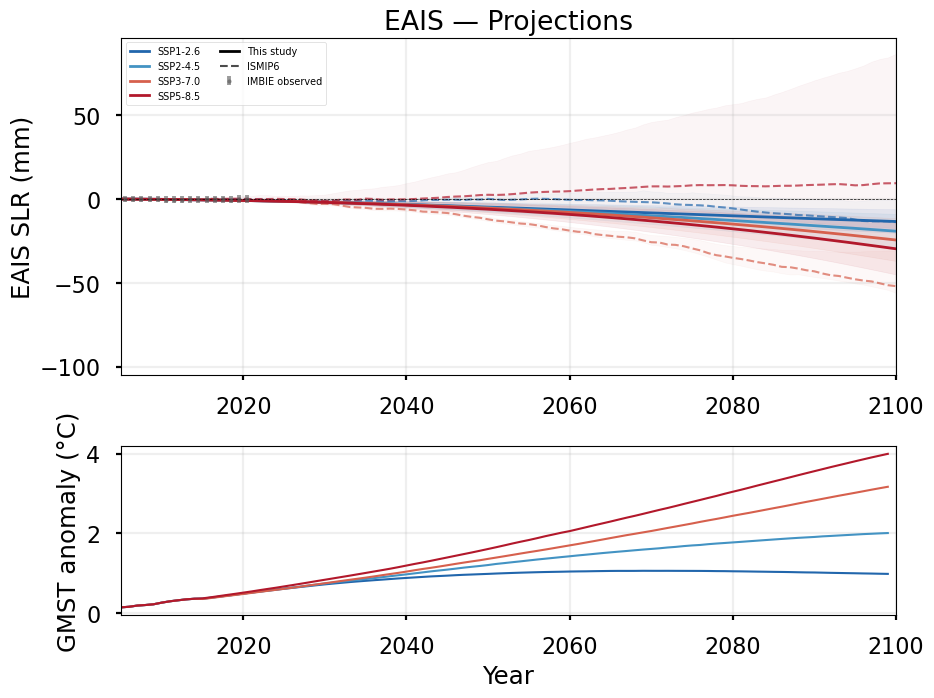

In [7]:
# ── Load ISMIP6 EAIS data for overlay on projection plot ──
from component_projections import read_ismip6_regional, ismip6_ensemble_stats

ISMIP6_BASE = f'{RAW_DIR}/ice_sheets/ismip6/ComputedScalarsPaper'
eais_ismip6 = read_ismip6_regional(ISMIP6_BASE, region=2)
print(f'ISMIP6 EAIS: {len(eais_ismip6)} model-experiment runs')

SSP_CODE = {'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
            'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585'}
EXP_GROUPS = {
    'SSP5-8.5': ['exp13'], 'SSP3-7.0': ['exp12'],
    'SSP1-2.6': ['exp10'], 'CMIP6 median': ['exp05', 'exp06'],
}

# Build temperature scenarios for lower panel
temp_scenarios = {}
for ssp_name, h5_key in SSP_H5_MAP.items():
    df_ssp = pd.read_hdf(H5_PATH, key=f'projections/temp/{h5_key}')
    hist_part = df_hist[df_hist['decimal_year'] < 2015].copy()
    combined = pd.concat([hist_part, df_ssp]).sort_index()
    combined = combined[~combined.index.duplicated(keep='last')]
    combined['temperature'] = combined['temperature'] - offset
    ann = combined.groupby(combined['decimal_year'].round(0)).agg(
        temperature=('temperature', 'mean')).reset_index()
    temp_scenarios[ssp_name] = {'years': ann['decimal_year'].values,
                                 'temperature': ann['temperature'].values}

# ── Two-panel projection plot with ISMIP6 overlay ──
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(10, 7.5))
gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1], hspace=0.28)
ax_sl = fig.add_subplot(gs[0])
ax_t = fig.add_subplot(gs[1])

proj_mask = (PROJ_YEARS >= 2005) & (PROJ_YEARS <= 2150)
yr_plot = PROJ_YEARS[proj_mask]

for ssp in PROJ_SSPS:
    color = SSP_COLORS.get(ssp, 'gray')
    p = eais_proj[ssp]
    med = p['median'][proj_mask] * M_TO_MM
    lo = p['p5'][proj_mask] * M_TO_MM
    hi = p['p95'][proj_mask] * M_TO_MM
    ax_sl.plot(yr_plot, med, color=color, lw=2, label=f'{ssp}')
    ax_sl.fill_between(yr_plot, lo, hi, color=color, alpha=0.08)

    # ISMIP6 ensemble overlay (dashed)
    exps = EXP_GROUPS.get(ssp)
    if exps:
        stats = ismip6_ensemble_stats(eais_ismip6, experiments=exps,
                                       baseline_year=BASELINE_YEAR)
        if stats is not None:
            ax_sl.plot(stats['time'], stats['median'] * M_TO_MM,
                       color=color, ls='--', lw=1.5, alpha=0.7)
            ax_sl.fill_between(stats['time'],
                               stats['p5'] * M_TO_MM, stats['p95'] * M_TO_MM,
                               color=color, alpha=0.04)

# Observations
ax_sl.errorbar(eais_year, eais_rebase * M_TO_MM, yerr=2 * eais_sigma * M_TO_MM,
               fmt='o', ms=3, color='0.35', alpha=0.6, label='IMBIE observed')
ax_sl.plot([], [], 'k-', lw=2, label='This study')
ax_sl.plot([], [], 'k--', lw=1.5, alpha=0.7, label='ISMIP6')
ax_sl.set_ylabel('EAIS SLR (mm)')
ax_sl.set_title('EAIS — Projections')
ax_sl.legend(fontsize=7, loc='upper left', ncol=2)
ax_sl.axhline(0, color='k', lw=0.5, ls='--')
ax_sl.set_xlim(2005, 2100)
ax_sl.grid(True, alpha=0.2)

# Temperature panel
for ssp in PROJ_SSPS:
    color = SSP_COLORS.get(ssp, 'gray')
    ts = temp_scenarios[ssp]
    mask_t = (ts['years'] >= 2005) & (ts['years'] <= 2150)
    ax_t.plot(ts['years'][mask_t], ts['temperature'][mask_t], color=color, lw=1.5)
ax_t.set_ylabel('GMST anomaly (°C)')
ax_t.set_xlabel('Year')
ax_t.set_xlim(2005, 2100)
ax_t.grid(True, alpha=0.2)

plt.savefig(f'{FIG_DIR}/component_eais_twopanel.png', dpi=150, bbox_inches='tight')
plt.show()

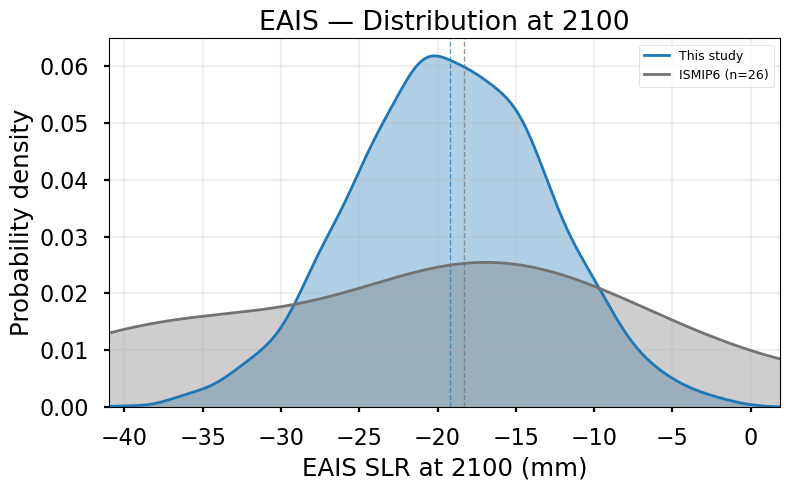

In [8]:
idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
HIST_SSP = 'SSP2-4.5'

our_samples = eais_proj[HIST_SSP]['samples'][:, idx_2100] * M_TO_MM

# ISMIP6 EAIS samples at 2100 (from individual model runs)
ismip6_exps = EXP_GROUPS.get(HIST_SSP, ['exp05', 'exp06'])
ismip6_vals_2100 = []
for key, val in eais_ismip6.items():
    if key[2] not in ismip6_exps:
        continue
    bl_idx = np.argmin(np.abs(val['time'] - BASELINE_YEAR))
    idx_end = np.argmin(np.abs(val['time'] - 2100))
    ismip6_vals_2100.append((val['sle_m'][idx_end] - val['sle_m'][bl_idx]) * M_TO_MM)

sample_sets = [our_samples]
labels = ['This study']
colors = ['tab:blue']
if len(ismip6_vals_2100) > 0:
    sample_sets.append(np.array(ismip6_vals_2100))
    labels.append(f'ISMIP6 (n={len(ismip6_vals_2100)})')
    colors.append('0.45')

plot_component_histogram(sample_sets, labels, colors, 'EAIS', year=2100,
                          save_path=f'{FIG_DIR}/component_eais_histogram_2100.png')

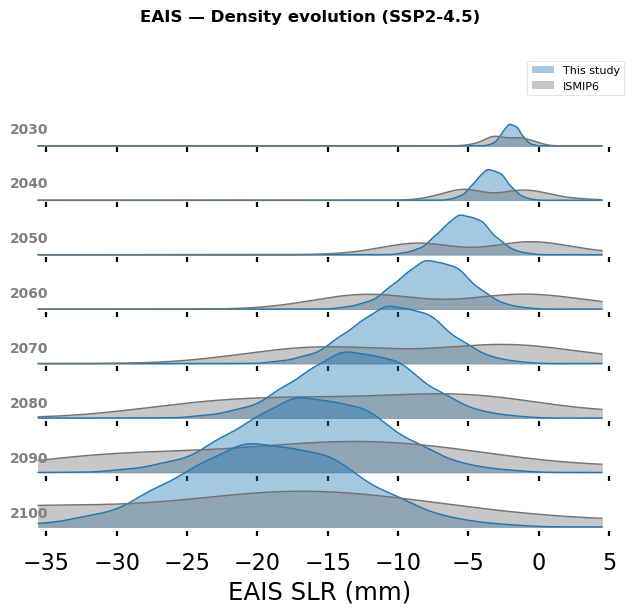

In [9]:
RIDGE_YEARS = list(range(2030, 2110, 10))
RIDGE_SSP = 'SSP2-4.5'
ismip6_exps_ridge = EXP_GROUPS.get(RIDGE_SSP, ['exp05', 'exp06'])

samples_by_year = {}
for yr in RIDGE_YEARS:
    idx_yr = np.argmin(np.abs(PROJ_YEARS - yr))
    year_dict = {'This study': eais_proj[RIDGE_SSP]['samples'][:, idx_yr] * M_TO_MM}

    # ISMIP6 values at this year
    ismip6_vals = []
    for key, val in eais_ismip6.items():
        if key[2] not in ismip6_exps_ridge:
            continue
        bl_idx = np.argmin(np.abs(val['time'] - BASELINE_YEAR))
        yr_idx = np.argmin(np.abs(val['time'] - yr))
        if np.abs(val['time'][yr_idx] - yr) < 5:
            ismip6_vals.append((val['sle_m'][yr_idx] - val['sle_m'][bl_idx]) * M_TO_MM)
    if len(ismip6_vals) > 0:
        year_dict['ISMIP6'] = np.array(ismip6_vals)

    samples_by_year[yr] = year_dict

plot_component_ridge(samples_by_year, 'EAIS', RIDGE_SSP,
                      source_colors={'This study': 'tab:blue', 'ISMIP6': '0.45'},
                      save_path=f'{FIG_DIR}/component_eais_ridge.png')

## 5. IPCC Comparison

EAIS is part of the total AIS component in IPCC AR6. Direct comparison requires
extracting the EAIS fraction, which is not straightforward from the aggregated NetCDFs.
We note that EAIS is expected to contribute near-zero or slightly negative SLR
(mass gain from increased snowfall), consistent with our trend-only model.

ISMIP6 EAIS: 77 total model-experiment runs


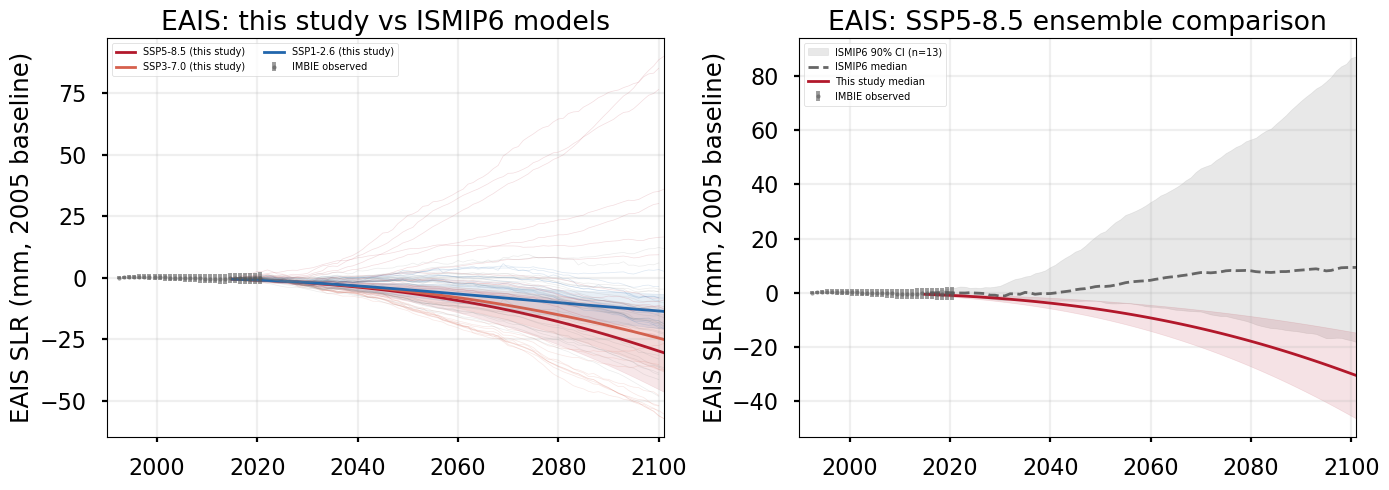


EAIS at 2100 (mm, relative to 2005):
SSP                        This study                ISMIP6    n
SSP5-8.5               -30 [-45, -14]         +9 [-18, +87]   13
SSP3-7.0               -24 [-37, -12]        -52 [-57, -31]   10
SSP1-2.6                -13 [-20, -6]         -14 [-21, -1]   12
CMIP6 median                                  -20 [-41, +3]   26


In [10]:
# ── ISMIP6 EAIS comparison (ivaf_region_2) ──
from component_projections import read_ismip6_regional, ismip6_ensemble_stats

ISMIP6_BASE = f'{RAW_DIR}/ice_sheets/ismip6/ComputedScalarsPaper'

# Read all SSP-mapped experiments for EAIS
eais_ismip6 = read_ismip6_regional(ISMIP6_BASE, region=2)
print(f'ISMIP6 EAIS: {len(eais_ismip6)} total model-experiment runs')

# Group by SSP-relevant experiments
EXP_GROUPS = {
    'SSP5-8.5': ['exp13'],
    'SSP3-7.0': ['exp12'],
    'SSP1-2.6': ['exp10'],
    'CMIP6 median': ['exp05', 'exp06'],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: ISMIP6 spaghetti + our projections
ax = axes[0]
proj_mask = (PROJ_YEARS >= 2015) & (PROJ_YEARS <= 2101)
yr_plot = PROJ_YEARS[proj_mask]

# Plot ISMIP6 individual runs (thin grey) and our median (colored)
for ssp_label, exps in EXP_GROUPS.items():
    color = SSP_COLORS.get(ssp_label, 'gray')
    # ISMIP6 individual trajectories
    for key, val in eais_ismip6.items():
        if key[2] not in exps:
            continue
        t = val['time']
        sle = val['sle_m']
        bl_idx = np.argmin(np.abs(t - BASELINE_YEAR))
        sle_rb = sle - sle[bl_idx]
        ax.plot(t, sle_rb * M_TO_MM, color=color, alpha=0.15, lw=0.5)

    # Our projection
    if ssp_label in eais_proj:
        p = eais_proj[ssp_label]
        ax.plot(yr_plot, p['median'][proj_mask] * M_TO_MM, color=color, lw=2,
                label=f'{ssp_label} (this study)')
        ax.fill_between(yr_plot, p['p5'][proj_mask] * M_TO_MM,
                        p['p95'][proj_mask] * M_TO_MM, color=color, alpha=0.1)

# Observations
ax.errorbar(eais_year, eais_rebase * M_TO_MM, yerr=2 * eais_sigma * M_TO_MM,
            fmt='o', ms=3, color='0.35', alpha=0.6, label='IMBIE observed')
ax.set_xlim(1990, 2101)
ax.set_ylabel('EAIS SLR (mm, 2005 baseline)')
ax.set_title('EAIS: this study vs ISMIP6 models')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.2)

# Panel B: Ensemble statistics for SSP5-8.5
ax = axes[1]
ssp_plot = 'SSP5-8.5'
exps_plot = EXP_GROUPS[ssp_plot]
stats = ismip6_ensemble_stats(eais_ismip6, experiments=exps_plot,
                               baseline_year=BASELINE_YEAR)
if stats is not None:
    color = SSP_COLORS.get(ssp_plot, 'C3')
    ax.fill_between(stats['time'], stats['p5'] * M_TO_MM, stats['p95'] * M_TO_MM,
                    color='0.7', alpha=0.3, label=f'ISMIP6 90% CI (n={stats["n_models"]})')
    ax.plot(stats['time'], stats['median'] * M_TO_MM, color='0.4', lw=2, ls='--',
            label='ISMIP6 median')

if ssp_plot in eais_proj:
    p = eais_proj[ssp_plot]
    ax.plot(yr_plot, p['median'][proj_mask] * M_TO_MM, color=color, lw=2,
            label='This study median')
    ax.fill_between(yr_plot, p['p5'][proj_mask] * M_TO_MM,
                    p['p95'][proj_mask] * M_TO_MM, color=color, alpha=0.12)

ax.errorbar(eais_year, eais_rebase * M_TO_MM, yerr=2 * eais_sigma * M_TO_MM,
            fmt='o', ms=3, color='0.35', alpha=0.6, label='IMBIE observed')
ax.set_xlim(1990, 2101)
ax.set_ylabel('EAIS SLR (mm, 2005 baseline)')
ax.set_title(f'EAIS: {ssp_plot} ensemble comparison')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_eais_ismip6.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f'\nEAIS at 2100 (mm, relative to {BASELINE_YEAR:.0f}):')
print(f'{"SSP":<16s} {"This study":>20s}  {"ISMIP6":>20s}  {"n":>3s}')
for ssp_label, exps in EXP_GROUPS.items():
    stats_s = ismip6_ensemble_stats(eais_ismip6, experiments=exps,
                                     baseline_year=BASELINE_YEAR)
    our = ''
    if ssp_label in eais_proj:
        idx = np.argmin(np.abs(PROJ_YEARS - 2100))
        p = eais_proj[ssp_label]
        our = f'{p["median"][idx]*M_TO_MM:+.0f} [{p["p5"][idx]*M_TO_MM:+.0f}, {p["p95"][idx]*M_TO_MM:+.0f}]'
    ism = ''
    n = 0
    if stats_s is not None:
        ism = f'{stats_s["median"][-1]*M_TO_MM:+.0f} [{stats_s["p5"][-1]*M_TO_MM:+.0f}, {stats_s["p95"][-1]*M_TO_MM:+.0f}]'
        n = stats_s['n_models']
    print(f'{ssp_label:<16s} {our:>20s}  {ism:>20s}  {n:>3d}')

## 6. Appendix: Sensitivity & Reviewer Q&A

### Justification for trend-only model
EAIS observations show near-zero net mass change with no clear temperature dependence.
The BIC comparison confirms that adding temperature sensitivity does not improve fit quality.
This is physically consistent: EAIS is gaining mass from increased precipitation
while marine-based sectors show limited dynamical change over the observational period.

In [11]:
F_MAX_VALUES = [1, 2, 3]

print(f'{"f_max":>5} {"a (mm/yr/°C²)":>16} {"b (mm/yr/°C)":>16} {"R²_lin":>8} {"R²_quad":>8} {"ΔBIC":>8}')
print('-' * 75)

for f_max in F_MAX_VALUES:
    sig_tapered = apply_sigma_taper(eais_sigma, eais_year, 2005, f_max)
    res_q = fit_bayesian_level(
        H_obs=eais_rebase, sigma_obs=sig_tapered,
        I2_obs=design_eais['I2_obs'], I1_obs=design_eais['I1_obs'],
        I0_obs=design_eais['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=200+f_max*100, **prior_kw)
    res_l = fit_bayesian_level(
        H_obs=eais_rebase, sigma_obs=sig_tapered,
        I2_obs=np.zeros_like(design_eais['I2_obs']),
        I1_obs=design_eais['I1_obs'], I0_obs=design_eais['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=300+f_max*100, **prior_kw)

    a_s = np.median(res_q.posterior_samples[:, 0]) * M_TO_MM
    b_s = np.median(res_l.posterior_samples[:, 1]) * M_TO_MM
    rss_q = np.sum(res_q.residuals**2)
    rss_l = np.sum(res_l.residuals**2)
    bic_q = n * np.log(rss_q/n) + 5*np.log(n)
    bic_l = n * np.log(rss_l/n) + 4*np.log(n)
    print(f'{f_max:>5} {a_s:>16.4f} {b_s:>16.4f} {res_l.r2:>8.4f} {res_q.r2:>8.4f} {bic_l-bic_q:>+8.1f}')

f_max    a (mm/yr/°C²)     b (mm/yr/°C)   R²_lin  R²_quad     ΔBIC
---------------------------------------------------------------------------
Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(mean=0.04 mm/yr/°C²), b~HN(0.1 mm/yr/°C), c~N(0.3, 1.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=0.754, b=-0.105, c=-0.053 mm/yr, σ_extra=0.10 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 821.87it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.014  ESS_bulk=167  ESS_tail=586
    alpha0: R-hat=1.024  ESS_bulk=190  ESS_tail=480
    trend: R-hat=1.017  ESS_bulk=243  ESS_tail=809
    log_sigma_extra: R-hat=1.017  ESS_bulk=215  ESS_tail=437
    H0: R-hat=1.014  ESS_bulk=230  ESS_tail=576
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.053, b=0.033, c=-0.025 mm/yr
  σ_extra: median=0.10 mm [0.01, 28.94]
  R² = -38.5393,  acceptance = 0.46
Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(mean=0.04 mm/yr/°C²), b~HN(0.1 mm/yr/°C), c~N(0.3, 1.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=0.000, b=0.072, c=-0.035 mm/yr, σ_extra=0.13 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 852.97it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.021  ESS_bulk=166  ESS_tail=198
    alpha0: R-hat=1.024  ESS_bulk=178  ESS_tail=305
    trend: R-hat=1.013  ESS_bulk=288  ESS_tail=665
    log_sigma_extra: R-hat=1.014  ESS_bulk=213  ESS_tail=330
    H0: R-hat=1.010  ESS_bulk=230  ESS_tail=402
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.045, b=0.026, c=-0.018 mm/yr
  σ_extra: median=0.09 mm [0.01, 0.31]
  R² = 0.5791,  acceptance = 0.47
    1           0.0434           0.0205   0.5791 -38.5393   -121.4
Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(mean=0.04 mm/yr/°C²), b~HN(0.1 mm/yr/°C), c~N(0.3, 1.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=0.754, b=-0.105, c=-0.053 mm/yr, σ_extra=0.10 mm


...

  Convergence diagnostics:
    dalpha_dT: R-hat=1.021  ESS_bulk=157  ESS_tail=402
    alpha0: R-hat=1.014  ESS_bulk=221  ESS_tail=422
    trend: R-hat=1.023  ESS_bulk=220  ESS_tail=772
    log_sigma_extra: R-hat=1.027  ESS_bulk=182  ESS_tail=437
    H0: R-hat=1.031  ESS_bulk=175  ESS_tail=594
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.041, b=0.026, c=-0.017 mm/yr
  σ_extra: median=0.11 mm [0.01, 0.38]
  R² = 0.5757,  acceptance = 0.47
    2           0.0432           0.0211   0.5757   0.7081     +6.5
Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(mean=0.04 mm/yr/°C²), b~HN(0.1 mm/yr/°C), c~N(0.3, 1.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=0.754, b=-0.105, c=-0.053 mm/yr, σ_extra=0.10 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 837.75it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.036  ESS_bulk=117  ESS_tail=521
    alpha0: R-hat=1.016  ESS_bulk=173  ESS_tail=424
    trend: R-hat=1.026  ESS_bulk=188  ESS_tail=685
    log_sigma_extra: R-hat=1.027  ESS_bulk=184  ESS_tail=383
    H0: R-hat=1.022  ESS_bulk=195  ESS_tail=560
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.053, b=0.038, c=-0.023 mm/yr
  σ_extra: median=0.14 mm [0.01, 0.44]
  R² = 0.6705,  acceptance = 0.49
Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(mean=0.04 mm/yr/°C²), b~HN(0.1 mm/yr/°C), c~N(0.3, 1.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=0.000, b=0.072, c=-0.035 mm/yr, σ_extra=0.13 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:06<00:00, 859.86it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.023  ESS_bulk=149  ESS_tail=284
    alpha0: R-hat=1.023  ESS_bulk=159  ESS_tail=415
    trend: R-hat=1.028  ESS_bulk=199  ESS_tail=727
    log_sigma_extra: R-hat=1.029  ESS_bulk=213  ESS_tail=488
    H0: R-hat=1.020  ESS_bulk=186  ESS_tail=601
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.045, b=0.028, c=-0.014 mm/yr
  σ_extra: median=0.13 mm [0.01, 0.44]
  R² = 0.4792,  acceptance = 0.47
    3           0.0411           0.0230   0.4792   0.6705     +8.6
